In [1]:
import json
from pathlib import Path
import jax
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from flax import serialization as sz
import pandas as pd
from numpyro.infer import NUTS, MCMC, init_to_median
import jax.random as jr
import numpyro
import os
import numpyro.distributions as dist
import pandas as pd

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Read all the data from the CSV files


In [2]:
df_9 = pd.read_csv("Posterior_samples/posterior_physical_params_full.csv")
df_9.head()

,x1_phys,x2_phys,x3_phys,x4_phys,sigma_0,sigma_1,sigma_2,sigma_3
0,0.617474,5797.2910,1.319479,10.198205,0.137854,0.088383,0.073283,0.048858
1,0.644486,3358.0112,2.259115,3.531771,0.100705,0.114849,0.069672,0.076848
2,0.650553,3373.2130,2.059227,3.993560,0.100176,0.120904,0.067836,0.080131
3,0.649647,3844.9750,2.124071,6.019075,0.133341,0.067659,0.116103,0.097352
4,0.667748,2137.5603,1.864080,1.251372,0.081420,0.142767,0.067061,0.087526


In [3]:
df_12 = pd.read_csv("Posterior_samples/posterior_physical_params_full_12Layers.csv")

In [21]:
df_6 = pd.read_csv("Posterior_samples/posterior_physical_params_full_6Layers.csv")
df_14 = pd.read_csv("Posterior_samples/posterior_physical_params_full_14Layers.csv")

# Collect all the physical vairables

In [6]:
n_L6 = df_6["x1_phys"].values
mu0_L6 = df_6["x2_phys"].values
muinf_L6 = df_6["x3_phys"].values
lam_L6 = df_6["x4_phys"].values

In [7]:
n_L9 = df_9["x1_phys"].values
mu0_L9 = df_9["x2_phys"].values
muinf_L9 = df_9["x3_phys"].values
lam_L9 = df_9["x4_phys"].values

In [8]:
n_L12 = df_12["x1_phys"].values
mu0_L12 = df_12["x2_phys"].values
muinf_L12 = df_12["x3_phys"].values
lam_L12 = df_12["x4_phys"].values

In [22]:
n_L14 = df_14["x1_phys"].values
mu0_L14 = df_14["x2_phys"].values
muinf_L14 = df_14["x3_phys"].values
lam_L14 = df_14["x4_phys"].values

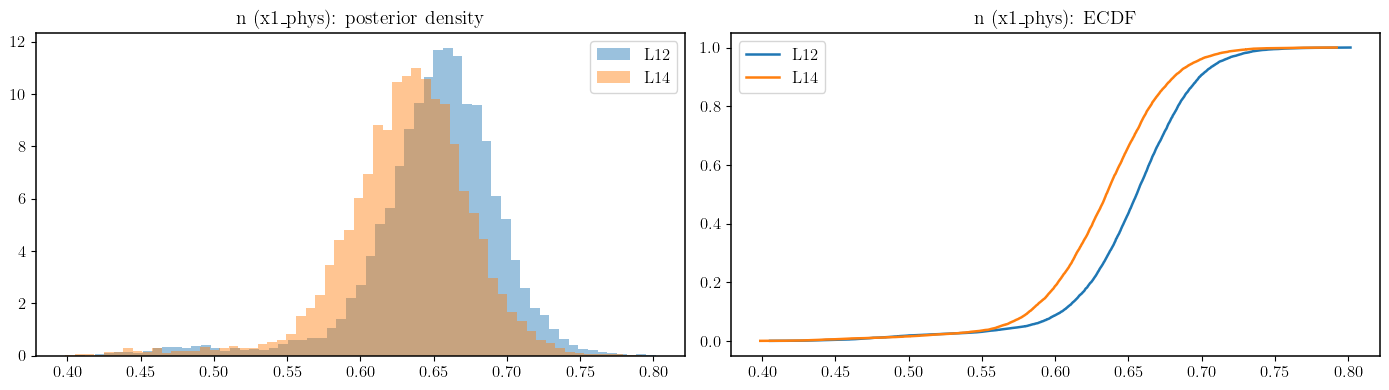


n (x1_phys)
  L12: median=0.655674, 90% HDI=[0.591948, 0.719863]
  L14: median=0.634964, 90% HDI=[0.568018, 0.698738]
  Δ(L14-L12): median=-0.020118, 90% HDI=[-0.104559, 0.0656162]
  P(Δ>0) = 0.281


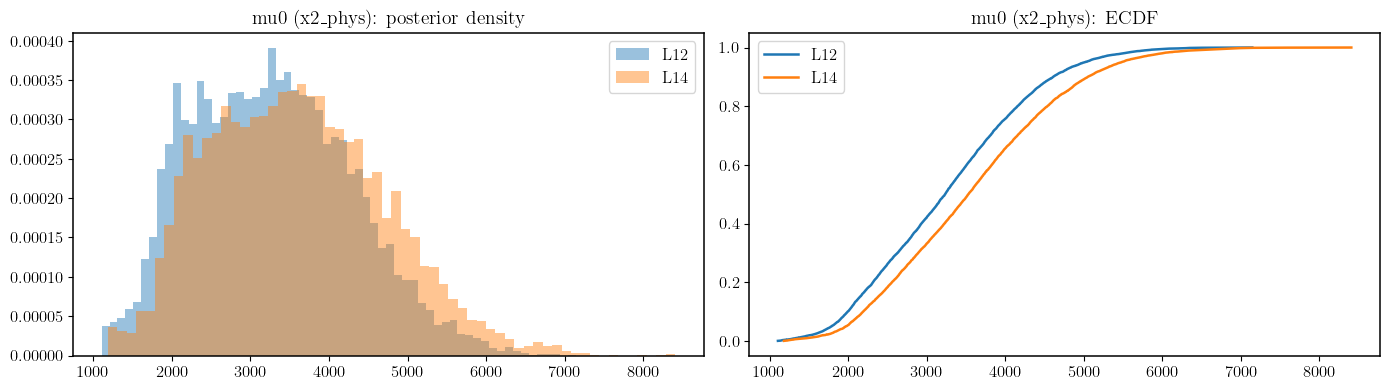


mu0 (x2_phys)
  L12: median=3234.97, 90% HDI=[1681.38, 4844.13]
  L14: median=3531.34, 90% HDI=[1843.9, 5296.9]
  Δ(L14-L12): median=291.943, 90% HDI=[-1722.36, 2335.15]
  P(Δ>0) = 0.627


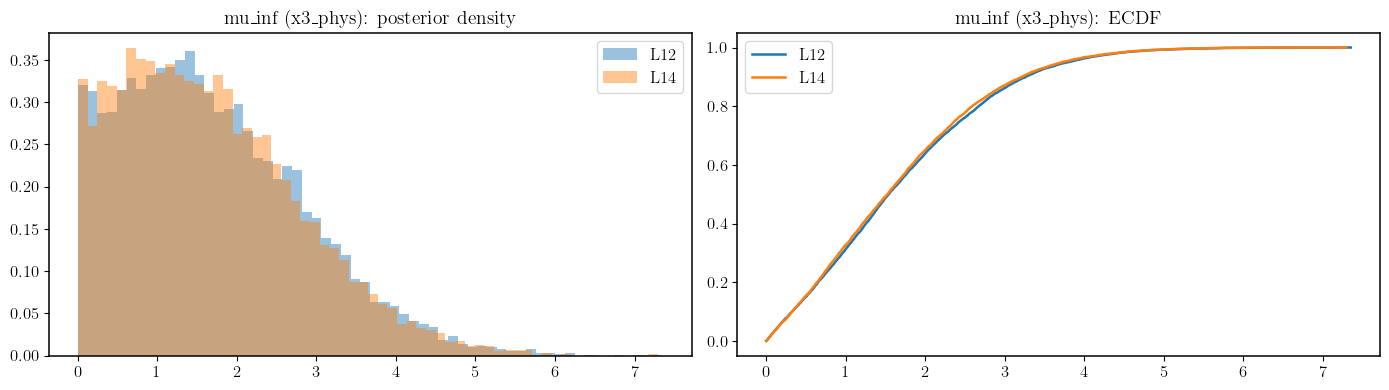


mu_inf (x3_phys)
  L12: median=1.54144, 90% HDI=[0.00205893, 3.26266]
  L14: median=1.52309, 90% HDI=[0.0014433, 3.21508]
  Δ(L14-L12): median=0.00102631, 90% HDI=[-2.26464, 2.00627]
  P(Δ>0) = 0.501


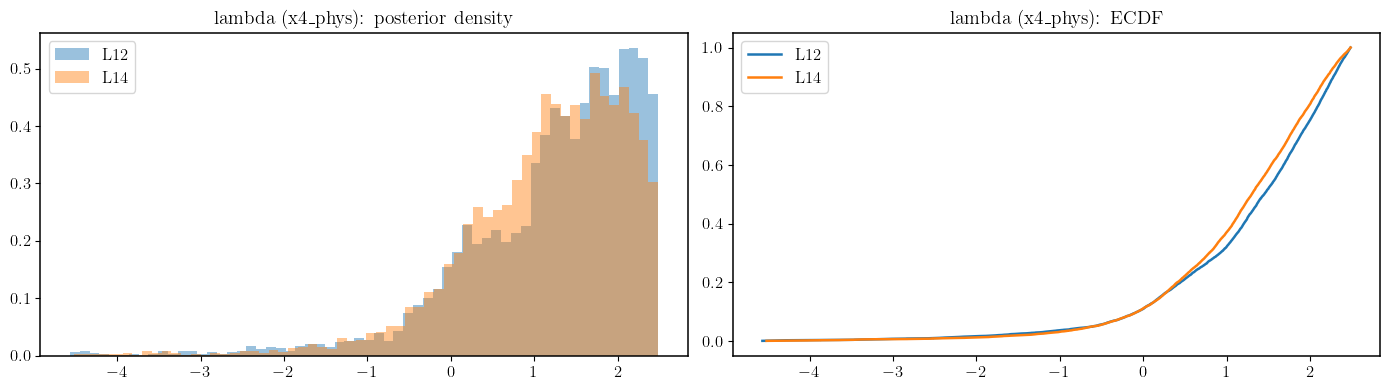


lambda (x4_phys)
  L12: median=1.4503, 90% HDI=[-0.0651617, 2.48386]
  L14: median=1.30149, 90% HDI=[-0.0662791, 2.48447]
  Δ(L14-L12): median=-0.0988805, 90% HDI=[-2.06183, 1.75684]
  P(Δ>0) = 0.435


In [23]:
# ----------- LaTeX style -----------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.usetex": True,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.linewidth": 1.1,
    "lines.linewidth": 1.8,
    "grid.alpha": 0.25,
})

# ---------- helpers ----------
def hdi(x, prob=0.9):
    """Highest density interval (approx) via sliding window on sorted samples."""
    x = np.sort(np.asarray(x))
    n = len(x)
    m = int(np.floor(prob * n))
    if m < 1:
        raise ValueError("Not enough samples for HDI.")
    widths = x[m:] - x[:n - m]
    i = np.argmin(widths)
    return x[i], x[i + m]

def ecdf(x):
    x = np.sort(np.asarray(x))
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

def compare_1d(name, a, b, label_a="L12", label_b="L14", bins=60):
    a = np.asarray(a); b = np.asarray(b)

    # --- summary stats + delta ---
    a_med = np.median(a); b_med = np.median(b)
    a_hdi = hdi(a, 0.9); b_hdi = hdi(b, 0.9)

    delta = b - a  # assumes same-length draws; if not, we’ll handle below
    if len(a) != len(b):
        # match by random pairing (still fine for delta distribution)
        m = min(len(a), len(b))
        rng = np.random.default_rng(0)
        aa = rng.choice(a, size=m, replace=False)
        bb = rng.choice(b, size=m, replace=False)
        delta = bb - aa

    d_med = np.median(delta)
    d_hdi = hdi(delta, 0.9)

    fig, axs = plt.subplots(1, 2, figsize=(14, 4))

    # --- (1) overlay density via normalized histogram ---
    axs[0].hist(a, bins=bins, density=True, alpha=0.45, label=label_a)
    axs[0].hist(b, bins=bins, density=True, alpha=0.45, label=label_b)
    axs[0].set_title(f"{name}: posterior density")
    axs[0].legend()

    # --- (2) ECDF ---
    xa, ya = ecdf(a)
    xb, yb = ecdf(b)
    axs[1].plot(xa, ya, label=label_a)
    axs[1].plot(xb, yb, label=label_b)
    axs[1].set_title(f"{name}: ECDF")
    axs[1].legend()

    plt.tight_layout()
    plt.show()

    print(f"\n{name}")
    print(f"  {label_a}: median={a_med:.6g}, 90% HDI=[{a_hdi[0]:.6g}, {a_hdi[1]:.6g}]")
    print(f"  {label_b}: median={b_med:.6g}, 90% HDI=[{b_hdi[0]:.6g}, {b_hdi[1]:.6g}]")
    print(f"  Δ({label_b}-{label_a}): median={d_med:.6g}, 90% HDI=[{d_hdi[0]:.6g}, {d_hdi[1]:.6g}]")
    print(f"  P(Δ>0) = {np.mean(delta>0):.3f}")

# ---------- run comparisons ----------
compare_1d("n (x1_phys)",    n_L12,    n_L14)
compare_1d("mu0 (x2_phys)",  mu0_L12,  mu0_L14)
compare_1d("mu_inf (x3_phys)", muinf_L12, muinf_L14)
compare_1d("lambda (x4_phys)", np.log(lam_L12), np.log(lam_L14))


In [15]:
def mu_bird_carreau(gdot, n, mu0, mu_inf, lam):
    """
    Bird–Carreau viscosity model:

        mu = mu_inf + (mu0 - mu_inf) * [1 + (lam * gdot)^2]^((n - 1)/2)

    Parameters
    ----------
    gdot : array-like
        shear rate
    n : float`
        power-law index
    mu0 : float
        zero-shear viscosity
    mu_inf : float
        infinite-shear viscosity
    lam : float
        time constant
    """
    gdot = np.asarray(gdot)
    return mu_inf + (mu0 - mu_inf) * (1.0 + (lam * gdot)**2)**((n - 1.0) / 2.0)

In [24]:
import numpy as np

def viscosity_envelope_from_phys(
    n_s, mu0_s, muinf_s, lam_s,
    gdot_min=1e-2, gdot_max=1e7, n_gdot=200,
    max_draws=2000, seed=0,
    q=(0.05, 0.5, 0.95),
):
    """
    Compute posterior viscosity envelope for Bird–Carreau viscosity model.

    Inputs
    ------
    n_s, mu0_s, muinf_s, lam_s : 1D arrays of posterior draws (same length preferred)
    mu_bird_carreau(gdot, n, mu0, muinf, lam) must exist.

    Returns
    -------
    gdot : (n_gdot,) array
    lo, med, hi : (n_gdot,) arrays corresponding to quantiles q
    """
    rng = np.random.default_rng(seed)

    n_s    = np.asarray(n_s)
    mu0_s  = np.asarray(mu0_s)
    muinf_s= np.asarray(muinf_s)
    lam_s  = np.asarray(lam_s)

    # shear-rate grid
    gdot = np.logspace(np.log10(gdot_min), np.log10(gdot_max), n_gdot)

    # subsample draws for speed
    S = min(len(n_s), len(mu0_s), len(muinf_s), len(lam_s))
    nd = min(S, max_draws)
    idx = rng.choice(S, size=nd, replace=False) if S > nd else np.arange(S)

    n_s, mu0_s, muinf_s, lam_s = n_s[idx], mu0_s[idx], muinf_s[idx], lam_s[idx]

    # compute viscosity curves: (nd, n_gdot)
    MU = np.empty((nd, n_gdot), dtype=float)
    for s in range(nd):
        MU[s, :] = mu_bird_carreau(gdot, n_s[s], mu0_s[s], muinf_s[s], lam_s[s])

    lo, med, hi = np.quantile(MU, q, axis=0)
    return gdot, lo, med, hi


In [25]:
gdot6, lo6, med6, hi6 = viscosity_envelope_from_phys(n_L6, mu0_L6, muinf_L6, lam_L6, seed=0)
gdot14, lo14, med14, hi14 = viscosity_envelope_from_phys(n_L12, mu0_L12, muinf_L12, lam_L12, seed=1)


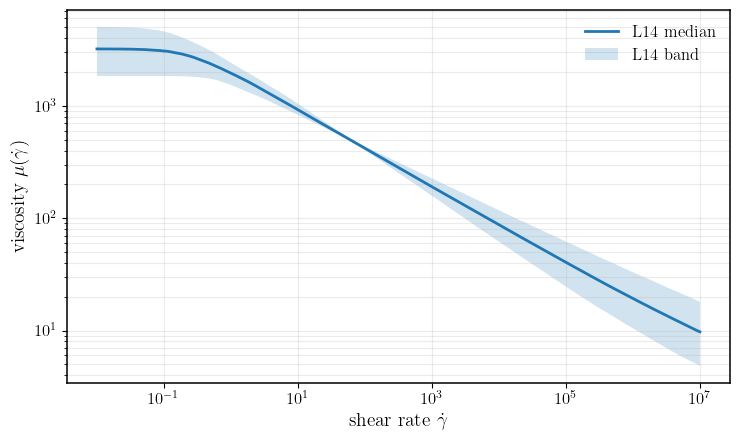

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7.5,4.5))
plt.plot(gdot14, med14, linewidth=2, label="L14 median")
plt.fill_between(gdot14, lo14, hi14, alpha=0.2, label="L14 band")

#plt.plot(gdot12, med12, linewidth=2, linestyle="--", label="L12 median")
#plt.fill_between(gdot12, lo12, hi12, alpha=0.2, label="L12 band")

plt.xscale("log"); plt.yscale("log")
plt.xlabel(r"shear rate $\dot\gamma$")
plt.ylabel(r"viscosity $\mu(\dot\gamma)$")
plt.grid(True, which="both", alpha=0.25)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()
